# 01 — Linear Regression from Scratch

**Goal:** code every piece of linear regression yourself — predict, cost, gradient, gradient descent — first with one feature, then generalized to multiple features. No sklearn, no shortcuts.

**Structure of this notebook:**
1. Setup + tiny toy dataset
2. Single-feature linear regression (predict → cost → gradient → gradient descent)
3. Multi-feature (vectorized) linear regression
4. Run on a slightly bigger dataset, plot the loss curve
5. Reference solutions (at the very bottom — don't peek early)

Each `TODO` cell has a function signature + docstring only. Write the code, run the sanity check cell right after it — it uses `assert`, so it will throw an error if your implementation is wrong. Don't move to the next section until the assert passes.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


---
## Part 1 — Single-Feature Linear Regression

Model: $f_{w,b}(x) = wx + b$

We'll use a tiny toy dataset you can basically compute by hand, so the sanity checks below are hand-verifiable if you want to double check them yourself.


In [2]:
# Toy dataset: single feature
x_train = np.array([1.0, 2.0, 3.0])
y_train = np.array([300.0, 500.0, 700.0])

print("x_train:", x_train)
print("y_train:", y_train)


x_train: [1. 2. 3.]
y_train: [300. 500. 700.]


### 1.1 — Predict (forward pass)

$$f_{w,b}(x^{(i)}) = w x^{(i)} + b$$

Implement the prediction function for a single feature.


In [43]:
def predict_single(x, w, b):
    """
    Compute prediction for single-feature linear regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        y_hat (ndarray (m,)): predicted values
    """
    # TODO: implement

    f_x = w * x + b

    return f_x


In [44]:
# Sanity check
w_test, b_test = 200.0, 100.0
y_hat = predict_single(x_train, w_test, b_test)
expected = np.array([300.0, 500.0, 700.0])

print("Your output:", y_hat)
print("Expected:   ", expected)
assert np.allclose(y_hat, expected), "predict_single output doesn't match expected values"
print("predict_single passed!")


Your output: [300. 500. 700.]
Expected:    [300. 500. 700.]
predict_single passed!


### 1.2 — Cost function

$$J(w,b) = \frac{1}{2m} \sum_{i=0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2$$

This is mean squared error, halved (the half makes the gradient cleaner later).


In [27]:
def compute_cost_single(x, y, w, b):
    """
    Compute cost for single-feature linear regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): target values
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        cost (scalar): mean squared error cost (halved)
    """
    # TODO: implement

    m = np.shape(x)[0]  # i got a little stuck in here as i wasnt using [0] to get the 3 as m 
    error = predict_single(x,w,b) - y 
    error_squared = error ** 2
    total_cost = np.sum(error_squared) / (2 * m)  

    return total_cost


In [28]:
# Sanity check
cost = compute_cost_single(x_train, y_train, 200.0, 100.0)
print("Your cost:", cost)
print("Expected:  0.0  (w=200, b=100 fits this data perfectly)")
assert np.isclose(cost, 0.0), "Cost should be 0 for perfectly fitting parameters"

cost2 = compute_cost_single(x_train, y_train, 0.0, 0.0)
print("\nYour cost (w=0, b=0):", cost2)
print("Expected:              " , np.sum(y_train**2) / (2*len(y_train)))
assert np.isclose(cost2, np.sum(y_train**2) / (2*len(y_train)))
print("compute_cost_single passed!")


Your cost: 0.0
Expected:  0.0  (w=200, b=100 fits this data perfectly)

Your cost (w=0, b=0): 138333.33333333334
Expected:               138333.33333333334
compute_cost_single passed!


### 1.3 — Gradient

$$\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{w,b}(x^{(i)}) - y^{(i)})$$


In [37]:
def compute_gradient_single(x, y, w, b):
    """
    Compute gradient for single-feature linear regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): target values
        w (scalar): weight parameter
        b (scalar): bias parameter

    Returns:
        dj_dw (scalar): gradient of cost w.r.t. w
        dj_db (scalar): gradient of cost w.r.t. b
    """
    # TODO: implement

    m = np.shape(x)[0]

    error = predict_single(x,w,b) - y 

    dj_dw = np.sum(error * x) / m

    dj_db = np.sum(error) / m 

    return dj_dw,dj_db


In [38]:
# Sanity check
dj_dw, dj_db = compute_gradient_single(x_train, y_train, 200.0, 100.0)
print("Your dj_dw, dj_db:", dj_dw, dj_db)
print("Expected:          0.0 0.0  (perfect fit -> zero gradient)")
assert np.isclose(dj_dw, 0.0) and np.isclose(dj_db, 0.0)

dj_dw2, dj_db2 = compute_gradient_single(x_train, y_train, 0.0, 0.0)
print("\nYour dj_dw, dj_db (w=0,b=0):", dj_dw2, dj_db2)
print("Expected:                    -1133.3333 -500.0")
assert np.isclose(dj_dw2, -1133.3333, atol=1e-3)
assert np.isclose(dj_db2, -500.0, atol=1e-3)
print("compute_gradient_single passed!")


Your dj_dw, dj_db: 0.0 0.0
Expected:          0.0 0.0  (perfect fit -> zero gradient)

Your dj_dw, dj_db (w=0,b=0): -1133.3333333333333 -500.0
Expected:                    -1133.3333 -500.0
compute_gradient_single passed!


### 1.4 — Gradient Descent

Now join predict → cost → gradient into full gradient descent:

$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

repeated for `num_iters` iterations.


In [41]:
def gradient_descent_single(x, y, w_init, b_init, alpha, num_iters):
    """
    Run gradient descent for single-feature linear regression.

    Args:
        x (ndarray (m,)): input feature values, m examples
        y (ndarray (m,)): target values
        w_init (scalar): initial weight
        b_init (scalar): initial bias
        alpha (scalar): learning rate
        num_iters (int): number of iterations to run

    Returns:
        w (scalar): final weight after training
        b (scalar): final bias after training
        cost_history (list): cost at every iteration (for plotting)
    """
    # TODO: implement
    # hint: use compute_gradient_single and compute_cost_single inside the loop
    w , b = w_init , b_init 
    cost_history = []

    for this_iteration in range(num_iters):
        dj_dw , dj_db = compute_gradient_single(x,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost_history.append(compute_cost_single(x,y,w,b))

    return w,b,cost_history 


Final w, b: 200.00002649781703 99.99993976423364
Expected:   ~200.0 ~100.0  (the data was generated from y = 200x + 100)
gradient_descent_single passed!


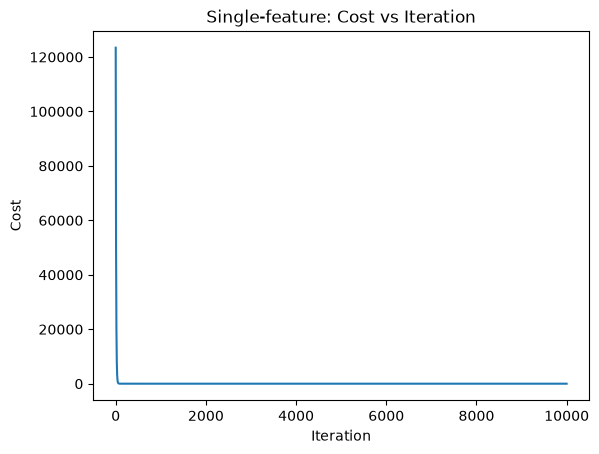

In [42]:
# Sanity check
w_final, b_final, cost_history = gradient_descent_single(
    x_train, y_train, w_init=0.0, b_init=0.0, alpha=0.01, num_iters=10000
)

print("Final w, b:", w_final, b_final)
print("Expected:   ~200.0 ~100.0  (the data was generated from y = 200x + 100)")
assert np.isclose(w_final, 200.0, atol=1.0)
assert np.isclose(b_final, 100.0, atol=1.0)
print("gradient_descent_single passed!")

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Single-feature: Cost vs Iteration")
plt.show()


---
## Part 2 — Multi-Feature (Vectorized) Linear Regression

Now generalize. With $n$ features, $w$ becomes a vector and each example $x^{(i)}$ becomes a vector too.

Model: $f_{\vec{w},b}(\vec{x}) = \vec{w} \cdot \vec{x} + b$

Use vectorized NumPy operations (`np.dot`, matrix ops) — no manual loops over features.


In [45]:
# Toy dataset: multiple features (e.g. size, bedrooms, age -> price)
X_train = np.array([
    [2104, 5, 45],
    [1416, 3, 40],
    [852,  2, 35]
], dtype=float)
y_train_multi = np.array([460.0, 232.0, 178.0])

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train_multi.shape)


X_train shape: (3, 3)
y_train shape: (3,)


### 2.1 — Predict (vectorized)

$$f_{\vec{w},b}(\vec{x}^{(i)}) = \vec{w} \cdot \vec{x}^{(i)} + b$$

For all examples at once: $f = X\vec{w} + b$


In [46]:
def predict_multi(X, w, b):
    """
    Compute predictions for multi-feature linear regression, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features each
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        y_hat (ndarray (m,)): predicted values
    """
    # TODO: implement (no loops over examples or features)
    
    return np.dot(X,w) + b


In [47]:
# Sanity check
w_test = np.array([0.1, 4.0, -2.0])
b_test = 80.0
y_hat = predict_multi(X_train, w_test, b_test)
expected = np.array([220.4, 153.6, 103.2])

print("Your output:", y_hat)
print("Expected:   ", expected)
assert np.allclose(y_hat, expected, atol=1e-6)
print("predict_multi passed!")


Your output: [220.4 153.6 103.2]
Expected:    [220.4 153.6 103.2]
predict_multi passed!


### 2.2 — Cost function (vectorized)

$$J(\vec{w},b) = \frac{1}{2m}\sum_{i=0}^{m-1}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})^2$$

Same formula as before, just with vector predictions.


In [51]:
def compute_cost_multi(X, y, w, b):
    """
    Compute cost for multi-feature linear regression.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        cost (scalar): mean squared error cost (halved)
    """
    # TODO: implement

    m = X.shape[0]
    error = predict_multi(X,w,b) - y 

    cost = np.sum(error ** 2) / (2 * m) 

    return cost


In [52]:
# Sanity check
cost = compute_cost_multi(X_train, y_train_multi, w_test, b_test)
print("Your cost:", cost)
print("Expected:  11524.96")
assert np.isclose(cost, 11524.96, atol=1.0)
print("compute_cost_multi passed!")


Your cost: 11524.96
Expected:  11524.96
compute_cost_multi passed!


### 2.3 — Gradient (vectorized)

$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})x_j^{(i)}$$

$$\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=0}^{m-1}(f_{\vec{w},b}(\vec{x}^{(i)}) - y^{(i)})$$

Vectorized hint: the whole $\vec{w}$ gradient can be computed as one matrix-vector product involving $X^T$ and the error vector.


In [64]:
def compute_gradient_multi(X, y, w, b):
    """
    Compute gradient for multi-feature linear regression, vectorized.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): target values
        w (ndarray (n,)): weight vector
        b (scalar): bias

    Returns:
        dj_dw (ndarray (n,)): gradient of cost w.r.t. w
        dj_db (scalar): gradient of cost w.r.t. b
    """
    # TODO: implement (no loops over features; a loop over examples is OK but a fully vectorized solution is better)
    m , n = X.shape

    dj_dw = np.zeros((n,))
    dj_db = 0.0

    error = (X @ w + b) - y
    
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    
    # for i in range(m):  
    #     error = (np.dot(X[i],w) + b) - y[i]
    #     for j in range(n):
    #         dj_dw[j] = dj_dw[j] + error * X[i,j]
    #     dj_db = dj_db + error   

    # dj_dw = dj_dw / m
    # dj_db = dj_db / m 

    return dj_dw,dj_db


In [65]:
# Sanity check
dj_dw, dj_db = compute_gradient_multi(X_train, y_train_multi, w_test, b_test)
expected_dj_dw = np.array([-226287.4667, -527.6, -5512.0])
expected_dj_db = -130.9333

print("Your dj_dw:", dj_dw)
print("Expected:  ", expected_dj_dw)
print("Your dj_db:", dj_db)
print("Expected:  ", expected_dj_db)

assert np.allclose(dj_dw, expected_dj_dw, atol=1.0)
assert np.isclose(dj_db, expected_dj_db, atol=0.01)
print("compute_gradient_multi passed!")


Your dj_dw: [-226287.4667    -527.6      -5512.    ]
Expected:   [-226287.4667    -527.6      -5512.    ]
Your dj_db: -130.93333333333334
Expected:   -130.9333
compute_gradient_multi passed!


### 2.4 — Gradient Descent (vectorized)

Join everything together, same update rule as before but now $\vec{w}$ is updated as a vector.


In [66]:
def gradient_descent_multi(X, y, w_init, b_init, alpha, num_iters):
    """
    Run gradient descent for multi-feature linear regression.

    Args:
        X (ndarray (m,n)): m examples, n features
        y (ndarray (m,)): target values
        w_init (ndarray (n,)): initial weight vector
        b_init (scalar): initial bias
        alpha (scalar): learning rate
        num_iters (int): number of iterations

    Returns:
        w (ndarray (n,)): final weight vector
        b (scalar): final bias
        cost_history (list): cost at every iteration
    """
    # TODO: implement
    cost_history = []
    w , b = w_init , b_init
    m, n = X.shape

    for iter in range(num_iters):
        dj_dw ,dj_db = compute_gradient_multi(X,y,w,b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db 
        
        cost_history.append(compute_cost_multi(X,y,w,b))

    return w , b , cost_history    




Final w: [ 0.2025  0.0011 -0.0093]
Final b: -0.0003572726308232225
Final cost: 694.9801923372239
Initial cost: 28989.121571723517
gradient_descent_multi passed! (cost decreased as expected)


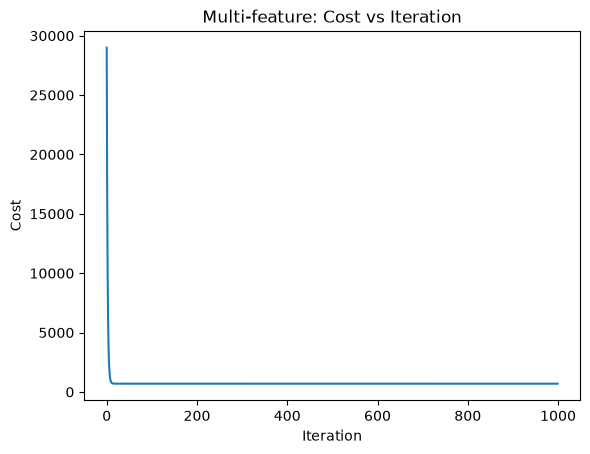

In [67]:
# Sanity check — note: raw features here have very different scales (size ~1000s vs bedrooms ~1-5),
# so we need a small learning rate and it will converge slowly. This is just to verify your loop is correct,
# not to get a great fit (we'll use feature scaling + real data in the next section).
w_init = np.zeros(X_train.shape[1])
b_init = 0.0

w_final, b_final, cost_history = gradient_descent_multi(
    X_train, y_train_multi, w_init, b_init, alpha=1e-7, num_iters=1000
)

print("Final w:", w_final)
print("Final b:", b_final)
print("Final cost:", cost_history[-1])
print("Initial cost:", cost_history[0])

assert cost_history[-1] < cost_history[0], "Cost should decrease over training"
assert len(cost_history) == 1000
print("gradient_descent_multi passed! (cost decreased as expected)")

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Multi-feature: Cost vs Iteration")
plt.show()


---
## Part 3 — Putting It Together on a Bigger Dataset

Let's generate a bigger synthetic dataset with 3 features and some noise, apply **feature scaling** (z-score normalization — you'll want this for real gradient descent to converge well), then run your `gradient_descent_multi` end-to-end and check the loss curve flattens out.


In [68]:
# Generate synthetic dataset: y = 3*x1 - 2*x2 + 5*x3 + 10 + noise
np.random.seed(42)
m = 200
X_big = np.random.rand(m, 3) * [50, 10, 100]   # different scales per feature, on purpose
true_w = np.array([3.0, -2.0, 5.0])
true_b = 10.0
noise = np.random.randn(m) * 5
y_big = X_big @ true_w + true_b + noise

print("X_big shape:", X_big.shape)
print("y_big shape:", y_big.shape)


X_big shape: (200, 3)
y_big shape: (200,)


### 3.1 — Feature scaling (z-score normalization)

$$x_j^{(i)} := \frac{x_j^{(i)} - \mu_j}{\sigma_j}$$

where $\mu_j$ is the mean and $\sigma_j$ is the standard deviation of feature $j$ across all examples.


In [ ]:
def zscore_normalize(X):
    """
    Normalize features using z-score normalization.

    Args:
        X (ndarray (m,n)): m examples, n features

    Returns:
        X_norm (ndarray (m,n)): normalized features
        mu (ndarray (n,)): mean of each feature
        sigma (ndarray (n,)): std dev of each feature
    """
    # TODO: implement
    pass


In [ ]:
# Sanity check
X_norm, mu, sigma = zscore_normalize(X_big)

print("Mean of normalized features (should be ~0):", np.mean(X_norm, axis=0))
print("Std of normalized features (should be ~1): ", np.std(X_norm, axis=0))

assert np.allclose(np.mean(X_norm, axis=0), 0, atol=1e-8)
assert np.allclose(np.std(X_norm, axis=0), 1, atol=1e-8)
print("zscore_normalize passed!")


In [ ]:
# Now run full gradient descent on the normalized big dataset
w_init = np.zeros(X_norm.shape[1])
b_init = 0.0

w_final, b_final, cost_history = gradient_descent_multi(
    X_norm, y_big, w_init, b_init, alpha=0.1, num_iters=1000
)

print("Final w (normalized space):", w_final)
print("Final b:", b_final)
print("Final cost:", cost_history[-1])

plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Big dataset (scaled): Cost vs Iteration — should flatten out")
plt.show()

print("\nNote: w_final won't directly match true_w=[3,-2,5] because we trained in normalized")
print("feature space. That's expected -- the point here is to see the loss curve converge cleanly.")


---
## You're done with the core implementation.

**Next up (separate lab):** `02_logistic_regression.ipynb` — sigmoid, log loss, gradient, gradient descent for classification.

**Reference solutions below** — only look if you're stuck or want to double check your approach after passing all asserts.


---
## Reference Solutions (don't peek until you've passed the asserts above)


In [35]:
# --- Part 1 reference ---

def predict_single_ref(x, w, b):
    return w * x + b

def compute_cost_single_ref(x, y, w, b):
    m = x.shape[0]
    y_hat = predict_single_ref(x, w, b)
    cost = np.sum((y_hat - y) ** 2) / (2 * m)
    return cost

def compute_gradient_single_ref(x, y, w, b):
    m = x.shape[0]
    y_hat = predict_single_ref(x, w, b)
    error = y_hat - y
    dj_dw = np.sum(error * x) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent_single_ref(x, y, w_init, b_init, alpha, num_iters):
    w, b = w_init, b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_single_ref(x, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_single_ref(x, y, w, b))
    return w, b, cost_history


In [ ]:
# --- Part 2 reference ---

def predict_multi_ref(X, w, b):
    return X @ w + b

def compute_cost_multi_ref(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_multi_ref(X, w, b)
    cost = np.sum((y_hat - y) ** 2) / (2 * m)
    return cost

def compute_gradient_multi_ref(X, y, w, b):
    m = X.shape[0]
    y_hat = predict_multi_ref(X, w, b)
    error = y_hat - y
    dj_dw = (X.T @ error) / m
    dj_db = np.sum(error) / m
    return dj_dw, dj_db

def gradient_descent_multi_ref(X, y, w_init, b_init, alpha, num_iters):
    w, b = w_init.copy(), b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_multi_ref(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        cost_history.append(compute_cost_multi_ref(X, y, w, b))
    return w, b, cost_history


In [ ]:
# --- Part 3 reference ---

def zscore_normalize_ref(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma
